In [1]:
import os
import sys
maindir = os.getcwd()
sys.path.append(maindir+"/src")

In [2]:
import pickle
import torch
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import data_processing, compute_anomalies_and_scalers, \
                            compute_forced_response, \
                            numpy_to_torch, scale_and_merge, \
                            rescale_training_and_test_sets, stack_runs_for_each_model

from leave_one_out import leave_one_out_procedure

from algorithms import ridge_regression, ridge_regression_low_rank, \
                        train_trace_norm,train_robust_weights, compute_gradient,train_robust_weights_trace_norm,\
                        prediction, compute_weights, prediction_training_set

In [3]:
############### Load climate model raw data for SST
with open('data/ssp585_time_series.pkl', 'rb') as f:
    data = pickle.load(f)

###################### Load longitude and latitude 
with open('data/lon.npy', 'rb') as f:
    lon = np.load(f)

with open('data/lat.npy', 'rb') as f:
    lat = np.load(f)

# define grid (+ croping for latitude > 60)
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')

lat_size = lat_grid.shape[0]
lon_size = lon_grid.shape[1]

In [15]:
# define pytorch precision
dtype = torch.float32

time_length = 165

data_processed, notnan_idx, nan_idx = data_processing(data, lon, lat,max_models=100)
x, means, vars = compute_anomalies_and_scalers(data_processed, lon_size, lat_size, nan_idx, time_period=time_length)
y = compute_forced_response(data_processed, lon_size, lat_size, nan_idx, time_period=time_length)

x,y, means, vars = numpy_to_torch(x,y,means,vars, dtype=dtype)

/home/vcohen/cope/src/preprocessing.py:94: RuntimeWarning: Mean of empty slice
  means[m] = np.nanmean(data_reshaped[m],axis=(0,1))
/home/vcohen/cope/src/preprocessing.py:101: RuntimeWarning: Degrees of freedom <= 0 for slice.
  vars[m] = np.nanvar(data_reshaped[m],axis=(0))
/home/vcohen/cope/src/preprocessing.py:169: RuntimeWarning: Mean of empty slice
  mean_spatial_ensemble = np.nanmean(y_tmp,axis=0)


In [16]:
m0 ='GISS-E2-2-G'

training_models, x_rescaled, y_rescaled = rescale_training_and_test_sets(m0,x,y,means,vars,dtype=dtype)
training_models, x_train, y_train, x_test, y_test  = scale_and_merge(m0,x_rescaled,y_rescaled,means,vars,dtype=dtype)
x_stacked, y_stacked = stack_runs_for_each_model(training_models, x_rescaled , y_rescaled)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


class Conv3dDenoisingAutoencoder(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv3d(in_channels, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv3d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((1,2,2))  # downsample spatially
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(16, 8, kernel_size=3, stride=(1,2,2), padding=1, output_padding=(0,0,0)),
            nn.ReLU(),
            nn.ConvTranspose3d(8, in_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        # print(f"Input shape: {x.shape}, Encoded shape: {z.shape}, Decoded shape: {out.shape}")
        # Pad if output is smaller
        pad_t = max(0, x.shape[2] - out.shape[2])
        pad_h = max(0, x.shape[3] - out.shape[3])
        pad_w = max(0, x.shape[4] - out.shape[4])
        if pad_t > 0 or pad_h > 0 or pad_w > 0:
            out = F.pad(out, (0, pad_w, 0, pad_h, 0, pad_t))
        # Crop if output is larger
        out = out[:, :, :x.shape[2], :x.shape[3], :x.shape[4]]
        return out

# Example usage
batch, channels, time, height, width = 8, 1, 165, lat_size,lon_size
x_tmp = torch.randn(batch, channels, time, height, width)
x_tmp = x_stacked.unsqueeze(1).reshape(x_stacked.shape[0], channels, time, lat_size, lon_size)
print(f"Input shape: {x_tmp.shape}")
y_tmp = y_stacked.unsqueeze(1).reshape(x_stacked.shape[0], channels, time, lat_size, lon_size)
print(f"Target shape: {y_tmp.shape}")

model = Conv3dDenoisingAutoencoder(in_channels=channels)

num_epochs = 10

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for epoch in range(num_epochs):
    model.train()
    noise = 0.1 * torch.randn_like(x_tmp)           # Add noise
    x_noisy = x_tmp + noise
    output = model(x_noisy)                     # Forward pass
    # loss = criterion(output, y_tmp)                 # Compare to clean input

    # Create mask for non-NaN values in the target
    mask = ~torch.isnan(y_tmp)
    # Replace NaNs in target with zero (so they don't propagate as NaN)
    y_tmp_masked = torch.where(mask, y_tmp, torch.zeros_like(y_tmp))
    output_masked = torch.where(mask, output, torch.zeros_like(output))

    # Compute loss only on valid (non-NaN) pixels
    loss = criterion(output_masked, y_tmp_masked)
    loss = loss * mask.float()  # Zero out loss where NaN
    loss = loss.sum() / mask.float().sum()  # Mean over valid pixels

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Input shape: torch.Size([686, 1, 165, 36, 72])
Target shape: torch.Size([686, 1, 165, 36, 72])
Epoch 0, Loss: nan
Epoch 1, Loss: nan
Epoch 2, Loss: nan


KeyboardInterrupt: 

In [24]:
import torch.nn as nn
import torch.optim as optim

class StackedDenoisingAutoencoder(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.encoders = nn.ModuleList([
            nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)
        ])
        self.decoders = nn.ModuleList([
            nn.Linear(dims[i+1], dims[i]) for i in reversed(range(len(dims)-1))
        ])
        self.activation = nn.ReLU()

    def forward(self, x):
        h = x
        for encoder in self.encoders:
            h = self.activation(encoder(h))
        for decoder in self.decoders:
            h = self.activation(decoder(h))
        return h


def add_noise(x, noise_factor=0.2):
    noise = noise_factor * torch.randn_like(x)
    return x + noise


# Example usage
batch_size, time_steps, features = 32, 165, len(notnan_idx)

# Flatten time and features for SDAE
x_flat = x_stacked[:,:,notnan_idx].view(x_stacked.shape[0], -1)  # shape: (32, 200)
y_flat = y_stacked[:,:,notnan_idx].view(y_stacked.shape[0], -1)  # shape: (32, 200)

dims = [time_steps * features, 64, 16]  # input_dim, hidden1, hidden2
sdae = StackedDenoisingAutoencoder(dims)
optimizer = optim.Adam(sdae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Training the Stacked Denoising Autoencoder
for epoch in range(100):
    
    x_noisy = add_noise(x_flat)
    x_hat = sdae(x_noisy)
    loss = criterion(x_hat, x_flat)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 1 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
# ...existing code...

Epoch 0, Loss: 142.2057
Epoch 1, Loss: 207.7669
Epoch 2, Loss: 258.4173
Epoch 3, Loss: 173.5091
Epoch 4, Loss: 142.6282
Epoch 5, Loss: 144.5037
Epoch 6, Loss: 148.9613
Epoch 7, Loss: 144.4872
Epoch 8, Loss: 142.4855
Epoch 9, Loss: 141.4428
Epoch 10, Loss: 141.4473
Epoch 11, Loss: 141.4579
Epoch 12, Loss: 141.4651


KeyboardInterrupt: 

In [73]:
y_pred = sdae(x_rescaled[m0][:,:,notnan_idx].view(x_rescaled[m0].shape[0], -1))
y_pred = y_pred.view(y_rescaled[m0].shape[0], time_length, -1)

In [74]:
# compute mse
mse = torch.mean((y_pred - y[m0][:,:,notnan_idx])**2)

print(f"Mean Squared Error: {mse.item():.4f}")

Mean Squared Error: 276.3431


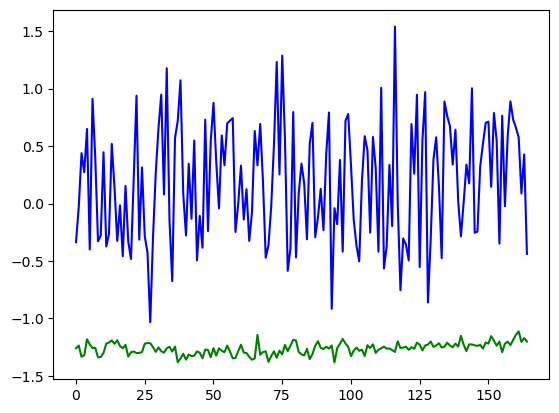

In [75]:
plt.close('all')
################# plot the rmse #################
fig, ax = plt.subplots()

# plot the ground truth in a specific location
idx_run = 0
idx_grid_cell = 100

time_period = time_length


# plot the ground truth
plt.plot(range(time_period),y[m0][idx_run,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='test',color='green')
# plt.plot(range(time_period),x_test_tmp[idx_run+1,:,notnan_idx[idx_grid_cell]].detach().numpy(),label='GT',color='pink')
plt.plot(range(time_period),y_pred[idx_run,:,idx_grid_cell].detach().numpy(),label='ridge',color='blue')
plt.show()

In [62]:
y[m0][:,:,notnan_idx]

tensor([[[-1.8366, -1.8002, -1.7360,  ..., -1.8600, -1.8602, -1.8611],
         [-1.8366, -1.7990, -1.7335,  ..., -1.8587, -1.8595, -1.8608],
         [-1.8373, -1.8062, -1.7563,  ..., -1.8563, -1.8568, -1.8577],
         ...,
         [-1.8459, -1.8091, -1.7422,  ..., -1.8417, -1.8423, -1.8427],
         [-1.8421, -1.8006, -1.7450,  ..., -1.8389, -1.8394, -1.8403],
         [-1.8393, -1.8035, -1.7500,  ..., -1.8393, -1.8402, -1.8419]],

        [[-1.8366, -1.8002, -1.7360,  ..., -1.8600, -1.8602, -1.8611],
         [-1.8366, -1.7990, -1.7335,  ..., -1.8587, -1.8595, -1.8608],
         [-1.8373, -1.8062, -1.7563,  ..., -1.8563, -1.8568, -1.8577],
         ...,
         [-1.8459, -1.8091, -1.7422,  ..., -1.8417, -1.8423, -1.8427],
         [-1.8421, -1.8006, -1.7450,  ..., -1.8389, -1.8394, -1.8403],
         [-1.8393, -1.8035, -1.7500,  ..., -1.8393, -1.8402, -1.8419]],

        [[-1.8366, -1.8002, -1.7360,  ..., -1.8600, -1.8602, -1.8611],
         [-1.8366, -1.7990, -1.7335,  ..., -1